In [1]:
import os
import pickle
import torch
from torch.utils.data import Dataset
import random

AA_TO_INDEX = {
    'A': 0, 'C': 1, 'D': 2, 'E': 3, 'F': 4,
    'G': 5, 'H': 6, 'I': 7, 'K': 8, 'L': 9,
    'M': 10, 'N': 11, 'P': 12, 'Q': 13, 'R': 14,
    'S': 15, 'T': 16, 'V': 17, 'W': 18, 'Y': 19,
    '-': 20, 'X': 20  # padding 또는 unknown
}

def random_voxel_rotate(voxel):
    # voxel: Tensor [C, D, H, W]
    if random.random() < 0.5:  # 50% 확률로 회전 적용
        axes = [(2, 3), (1, 3), (1, 2)]  # (H, W), (D, W), (D, H)
        k = random.choice([1, 2, 3])  # 실제 회전만 (0 제외)
        axis = random.choice(axes)
        voxel = torch.rot90(voxel, k=k, dims=axis)
    return voxel

def random_voxel_flip(voxel):
    if random.random() < 0.5:
        voxel = torch.flip(voxel, dims=[1])  # D-axis flip
    if random.random() < 0.5:
        voxel = torch.flip(voxel, dims=[2])  # H-axis flip
    if random.random() < 0.5:
        voxel = torch.flip(voxel, dims=[3])  # W-axis flip
    return voxel

class VoxelDataset(Dataset):
    def __init__(self, df, voxel_cache_dir, aug=False):
        self.df = df.reset_index(drop=True)
        self.voxel_cache_dir = voxel_cache_dir
        self.aug = aug

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        uid = row["UniProtID"]
        mut_pos = row["MutPos"]
        wt = row["WT"]
        mut = row["Mut"]
        label = row["Label"]

        key = f"{uid}_{mut_pos}"
        voxel_path = os.path.join(self.voxel_cache_dir, f"{key}.pkl")

        # Load voxel
        with open(voxel_path, "rb") as f:
            data = pickle.load(f)
            feature = data["feature"]  # shape: (1, 7, 7, 7, 63)

        # Preprocess
        feature_tensor = torch.from_numpy(feature).permute(0, 4, 1, 2, 3).float().squeeze(0)  # (63, 7, 7, 7)

        if self.aug:
            feature_tensor = random_voxel_rotate(feature_tensor)
            feature_tensor = random_voxel_flip(feature_tensor)

        # Convert WT/Mut AA to index
        ref_idx = torch.tensor(AA_TO_INDEX.get(str(wt), 20), dtype=torch.long)
        mut_idx = torch.tensor(AA_TO_INDEX.get(str(mut), 20), dtype=torch.long)

        return feature_tensor, ref_idx, mut_idx, torch.tensor(label).float()

In [2]:
import torch
import torch.nn as nn

class VoxelMBConvClassifier(nn.Module):
    def __init__(self, in_ch=63, emb_dim=128, dropout_p=0.3):
        super().__init__()
        self.backbone = nn.Sequential(
            MBConv3D(in_ch, 64, expand_ratio=6),
            MBConv3D(64, 64, expand_ratio=6),
            MBConv3D(64, emb_dim, expand_ratio=6)
        )
        self.pool = nn.AdaptiveAvgPool3d(1)  # → [B, 128, 1, 1, 1]
        self.classifier = nn.Sequential(
            nn.Flatten(),                             # → [B, 128]
            nn.Linear(emb_dim, emb_dim),
            nn.BatchNorm1d(emb_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_p),
            nn.Linear(emb_dim, 1),
            nn.Sigmoid()  # Binary classification
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x.squeeze(-1)


class SqueezeExcitation3D(nn.Module):
    def __init__(self, in_channels, reduction=24):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool3d(1)
        self.se = nn.Sequential(
            nn.Conv3d(in_channels, in_channels // reduction, kernel_size=1),
            nn.SiLU(),
            nn.Conv3d(in_channels // reduction, in_channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.se(self.pool(x))
        return x * scale

class MBConv3D(nn.Module):
    def __init__(self, in_ch, out_ch, expand_ratio=6, kernel_size=3, stride=1, se_reduction=24):
        super().__init__()
        mid_ch = in_ch * expand_ratio

        self.use_res_connect = (stride == 1 and in_ch == out_ch)

        self.expand = nn.Sequential(
            nn.Conv3d(in_ch, mid_ch, kernel_size=1, bias=False),
            nn.BatchNorm3d(mid_ch),
            nn.SiLU()
        ) if expand_ratio != 1 else nn.Identity()

        self.depthwise = nn.Sequential(
            nn.Conv3d(mid_ch, mid_ch, kernel_size=kernel_size, stride=stride,
                      padding=kernel_size//2, groups=mid_ch, bias=False),
            nn.BatchNorm3d(mid_ch),
            nn.SiLU()
        )

        self.se = SqueezeExcitation3D(mid_ch, reduction=se_reduction)

        self.project = nn.Sequential(
            nn.Conv3d(mid_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm3d(out_ch)
        )

    def forward(self, x):
        identity = x
        out = self.expand(x)
        out = self.depthwise(out)
        out = self.se(out)
        out = self.project(out)

        if self.use_res_connect:
            return out + identity
        else:
            return out

class VoxelMBConvClassifier(nn.Module):
    def __init__(self, in_ch=63, emb_dim=128, dropout_p=0.3):
        super().__init__()
        
        # 3D 구조 백본
        self.backbone = nn.Sequential(
            MBConv3D(in_ch, 32, expand_ratio=6),     # [7×7×7]
            MBConv3D(32, 32, expand_ratio=6),
            MBConv3D(32, 48, expand_ratio=6),
            MBConv3D(48, 48, expand_ratio=6),
            MBConv3D(48, 64, expand_ratio=6),
            MBConv3D(64, 64, expand_ratio=6, stride=2),  # 다운샘플링: → [4×4×4]
            MBConv3D(64, 64, expand_ratio=6),
            MBConv3D(64, 96, expand_ratio=6),
            MBConv3D(96, 96, expand_ratio=6),
            MBConv3D(96, 96, expand_ratio=6),
            MBConv3D(96, 96, expand_ratio=6),
            MBConv3D(96, 96, expand_ratio=6),
            MBConv3D(96, emb_dim, expand_ratio=6),
            MBConv3D(emb_dim, emb_dim, expand_ratio=6),
            MBConv3D(emb_dim, emb_dim, expand_ratio=6)
        )
        self.pool = nn.AdaptiveAvgPool3d(1)  # → [B, 128, 1, 1, 1]

        # Mutation Embedding (64 + 64 → 128)
        self.ref_emb = nn.Embedding(21, emb_dim // 2)  # 64
        self.mut_emb = nn.Embedding(21, emb_dim // 2)  # 64
        self.mut_fusion = nn.Sequential(
            nn.Linear(emb_dim, emb_dim),
            nn.BatchNorm1d(emb_dim),
            nn.SiLU(),
            nn.Linear(emb_dim, emb_dim),
            nn.BatchNorm1d(emb_dim),
            nn.SiLU()
        )

        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(emb_dim, emb_dim),
            nn.BatchNorm1d(emb_dim),
            nn.SiLU(),
            nn.Dropout(dropout_p),
            nn.Linear(emb_dim, 2)  # Binary classification (logit)
        )

    def forward(self, x, ref_idx, mut_idx):
        x = self.backbone(x)               # [B, 128, 7, 7, 7]
        x = self.pool(x).squeeze(-1).squeeze(-1).squeeze(-1)  # → [B, 128]

        # Mutation embedding
        ref_vec = self.ref_emb(ref_idx)    # [B, 64]
        mut_vec = self.mut_emb(mut_idx)    # [B, 64]
        mut_feat = self.mut_fusion(torch.cat([ref_vec, mut_vec], dim=1))  # [B, 128]

        # Combine structure & mutation features
        x = x + mut_feat                   # [B, 128]

        return self.classifier(x)          # [B, 2]

In [3]:
from torch.utils.data import DataLoader
import pandas as pd
from sklearn.model_selection import KFold

df = pd.read_csv("/mnt/c/Users/Kunny/Research/Project/BiConVarNet/ARSA/sample_data.tsv", sep="\t")


voxel_cache_dir = "/mnt/c/Users/Kunny/Research/Dataset/Missense_Variant_dataset/voxel_cache"

test_dataset   = VoxelDataset(df, voxel_cache_dir)
test_loader   = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=0)

In [4]:
df

,UniProtID,MutPos,WT,Mut,Label,StructureFile
0,P15289,23,I,V,0.647,AF-P15289-F1-model_v4.pdb
1,P15289,29,D,N,0.575,AF-P15289-F1-model_v4.pdb
2,P15289,29,D,E,0.533,AF-P15289-F1-model_v4.pdb
3,P15289,30,D,H,0.459,AF-P15289-F1-model_v4.pdb
4,P15289,31,L,P,0.599,AF-P15289-F1-model_v4.pdb
...,...,...,...,...,...,...
344,P15289,494,T,I,0.734,AF-P15289-F1-model_v4.pdb
345,P15289,496,R,L,0.718,AF-P15289-F1-model_v4.pdb
346,P15289,496,R,H,0.796,AF-P15289-F1-model_v4.pdb
347,P15289,496,R,P,0.416,AF-P15289-F1-model_v4.pdb


In [8]:
import torch
import torch.nn as nn
from sklearn.metrics import mean_squared_error, roc_auc_score
from scipy.stats import pearsonr, kendalltau
from tqdm import tqdm
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = VoxelMBConvClassifier(in_ch=63, emb_dim=128, dropout_p=0.3).to(device)
model.load_state_dict(torch.load("/mnt/e/CAGI_data/best_model_250805_struct.pth"))
model.eval()

val_loss = 0
all_probs = []
all_labels = []

criterion = nn.CrossEntropyLoss()

def temperature_scaled_softmax(logits, T=2.0):
    return torch.softmax(logits / T, dim=1)

from sklearn.preprocessing import QuantileTransformer

with torch.no_grad():
    for x, ref_idx, mut_idx, y in tqdm(test_loader, desc="Evaluating"):
        x = x.to(device)
        ref_idx = ref_idx.to(device)
        mut_idx = mut_idx.to(device)
        y = y.to(device)

        logits = model(x, ref_idx, mut_idx)  # [B, 2]

        probs = 1- torch.softmax(logits, dim=1)[:, 1]  # class=0 → benign → WT activity

        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

# Convert to numpy arrays
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

# qt = QuantileTransformer(output_distribution='uniform')
# all_probs = qt.fit_transform(all_probs.reshape(-1, 1)).reshape(-1)

# === Evaluation Metrics ===
mse = mean_squared_error(all_labels, all_probs)
pearson_r, _ = pearsonr(all_labels, all_probs)
kendall_tau, _ = kendalltau(all_labels, all_probs)

try:
    binary_labels = (all_labels >= 0.5).astype(int)
    auc = roc_auc_score(binary_labels, all_probs)
except:
    auc = float('nan')

# === Print Results ===
print(f"MSE:              {mse:.4f}")
print(f"Pearson r:        {pearson_r:.4f}")
print(f"Kendall's Tau:    {kendall_tau:.4f}")
print(f"AUC (bin@0.5):    {auc:.4f}")


Evaluating: 100%|██████████| 349/349 [00:05<00:00, 63.01it/s]


MSE:              0.1231
Pearson r:        0.3761
Kendall's Tau:    0.2400
AUC (bin@0.5):    0.6425


In [27]:
qt = QuantileTransformer(output_distribution='normal')
all_probs_2 = qt.fit_transform(all_probs.reshape(-1, 1)).reshape(-1)

# === Evaluation Metrics ===
mse = mean_squared_error(all_labels, all_probs_2)
pearson_r, _ = pearsonr(all_labels, all_probs_2)
kendall_tau, _ = kendalltau(all_labels, all_probs_2)

try:
    binary_labels = (all_labels >= 0.5).astype(int)
    auc = roc_auc_score(binary_labels, all_probs_2)
except:
    auc = float('nan')

# === Print Results ===
print(f"MSE:              {mse:.4f}")
print(f"Pearson r:        {pearson_r:.4f}")
print(f"Kendall's Tau:    {kendall_tau:.4f}")
print(f"AUC (bin@0.5):    {auc:.4f}")


MSE:              1.3939
Pearson r:        0.3296
Kendall's Tau:    0.2517
AUC (bin@0.5):    0.6430


/home/kunny/miniconda3/envs/mamba_env/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:2846: UserWarning: n_quantiles (1000) is greater than the total number of samples (349). n_quantiles is set to n_samples.
  warnings.warn(


In [12]:
df

,UniProtID,MutPos,WT,Mut,Label,StructureFile
0,P15289,23,I,V,0.647,AF-P15289-F1-model_v4.pdb
1,P15289,29,D,N,0.575,AF-P15289-F1-model_v4.pdb
2,P15289,29,D,E,0.533,AF-P15289-F1-model_v4.pdb
3,P15289,30,D,H,0.459,AF-P15289-F1-model_v4.pdb
4,P15289,31,L,P,0.599,AF-P15289-F1-model_v4.pdb
...,...,...,...,...,...,...
344,P15289,494,T,I,0.734,AF-P15289-F1-model_v4.pdb
345,P15289,496,R,L,0.718,AF-P15289-F1-model_v4.pdb
346,P15289,496,R,H,0.796,AF-P15289-F1-model_v4.pdb
347,P15289,496,R,P,0.416,AF-P15289-F1-model_v4.pdb


In [59]:
def squash_monotonic(p, method="exp", strength=2.0):
    """단조감소 + 비선형 flatten을 위한 heuristic squash 함수"""
    p = np.clip(p, 1e-5, 1 - 1e-5)

    if method == "exp":
        return (1 - np.exp(-strength * (1 - p))) / (1 - np.exp(-strength))  # flatten
    elif method == "log":
        return np.log(1 + strength * (1 - p)) / np.log(1 + strength)
    elif method == "power":
        return (1 - p) ** (1 / strength)
    else:
        raise ValueError("Unknown method")
    
all_probs_2 = squash_monotonic(all_probs, method="exp", strength=1.0)

# === Evaluation Metrics ===
mse = mean_squared_error(all_labels, all_probs_2)
pearson_r, _ = pearsonr(all_labels, all_probs_2)
kendall_tau, _ = kendalltau(all_labels, all_probs_2)

try:
    binary_labels = (all_labels >= 0.5).astype(int)
    auc = roc_auc_score(binary_labels, all_probs_2)
except:
    auc = float('nan')

# === Print Results ===
print(f"MSE:              {mse:.4f}")
print(f"Pearson r:        {pearson_r:.4f}")
print(f"Kendall's Tau:    {kendall_tau:.4f}")
print(f"AUC (bin@0.5):    {auc:.4f}")


MSE:              0.1246
Pearson r:        0.3657
Kendall's Tau:    0.2517
AUC (bin@0.5):    0.6430


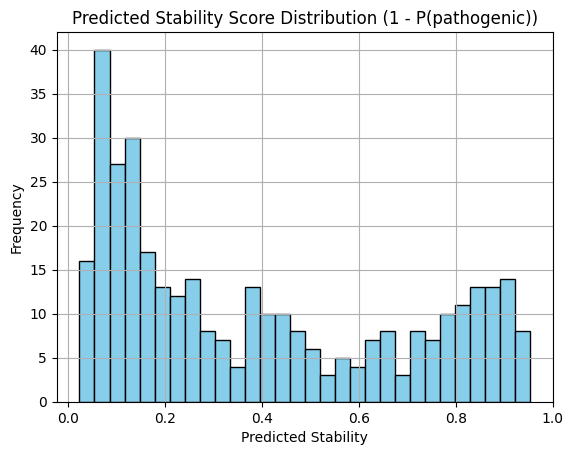

In [11]:
import matplotlib.pyplot as plt

plt.hist(all_probs, bins=30, color='skyblue', edgecolor='black')
plt.title("Predicted Stability Score Distribution (1 - P(pathogenic))")
plt.xlabel("Predicted Stability")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.hist(all_probs, bins=30, color='skyblue', edgecolor='black')
plt.title("Predicted Stability Score Distribution (1 - P(pathogenic))")
plt.xlabel("Predicted Stability")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()